SRTM Calibration Module 

In [1]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling

In [2]:
def build_target_profile_from_image(image_path: str) -> dict:
    with rasterio.open(image_path) as src:
        return {
            "crs": src.crs,
            "transform": src.transform,
            "width": src.width,
            "height": src.height,
        }

print("Function defined: build_target_profile_from_image")

Function defined: build_target_profile_from_image


In [3]:
def load_srtm_as_prior(srtm_path: str, target_profile: dict) -> np.ndarray:
    with rasterio.open(srtm_path) as src:
        dst_array = np.empty((target_profile["height"], target_profile["width"]),
                              dtype=np.float32)
        reproject(
            source=rasterio.band(src, 1),
            destination=dst_array,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=target_profile["transform"],
            dst_crs=target_profile["crs"],
            resampling=Resampling.bilinear,  # smooth interpolation, avoids blocky steps
        )
    return dst_array

print("Function defined: load_srtm_as_prior")

Function defined: load_srtm_as_prior


In [4]:
def sample_gcps_from_srtm(srtm_prior: np.ndarray, n_points: int = 200,
                           seed: int = 42) -> np.ndarray:
    rng = np.random.default_rng(seed)
    h, w = srtm_prior.shape
    rows = rng.integers(0, h, size=n_points)
    cols = rng.integers(0, w, size=n_points)
    elevations = srtm_prior[rows, cols]
    return np.stack([rows, cols, elevations], axis=1)

print("Function defined: sample_gcps_from_srtm")

Function defined: sample_gcps_from_srtm


In [5]:
def simple_scale_shift_calibration(relative_depth: np.ndarray,
                                    srtm_prior: np.ndarray) -> np.ndarray:
    x = relative_depth.flatten()
    y = srtm_prior.flatten()

    valid = np.isfinite(x) & np.isfinite(y)
    x_valid, y_valid = x[valid], y[valid]

    # Least-squares fit: y = a*x + b
    A = np.vstack([x_valid, np.ones_like(x_valid)]).T
    a, b = np.linalg.lstsq(A, y_valid, rcond=None)[0]

    calibrated = a * relative_depth + b
    return calibrated.astype(np.float32)

print("Function defined: simple_scale_shift_calibration")

Function defined: simple_scale_shift_calibration


In [6]:
def export_geotiff(array: np.ndarray, reference_profile: dict, out_path: str):
    profile = {
        "driver": "GTiff",
        "height": array.shape[0],
        "width": array.shape[1],
        "count": 1,
        "dtype": "float32",
        "crs": reference_profile["crs"],
        "transform": reference_profile["transform"],
        "nodata": -9999,
    }
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(array.astype(np.float32), 1)
    print(f"Saved -> {out_path}")

print("Function defined: export_geotiff")

Function defined: export_geotiff


In [7]:
h, w = 128, 128
fake_relative_depth = np.random.rand(h, w).astype(np.float32)              # 0-1
fake_srtm_prior = (fake_relative_depth * 40 + 10 +                         # roughly correlated
                    np.random.normal(0, 2, (h, w))).astype(np.float32)      # + noise

print("fake_relative_depth shape:", fake_relative_depth.shape, "range:", fake_relative_depth.min(), "-", fake_relative_depth.max())
print("fake_srtm_prior shape:", fake_srtm_prior.shape, "range:", fake_srtm_prior.min(), "-", fake_srtm_prior.max())

fake_relative_depth shape: (128, 128) range: 1.0735896e-05 - 0.9999608
fake_srtm_prior shape: (128, 128) range: 5.6279016 - 55.68609


In [8]:
gcps = sample_gcps_from_srtm(fake_srtm_prior, n_points=50)
print(f"Sampled {len(gcps)} GCPs.")
print("First 5 rows [row, col, elevation_m]:")
gcps[:5]

Sampled 50 GCPs.
First 5 rows [row, col, elevation_m]:


array([[11.        , 97.        , 17.6409111 ],
       [99.        , 24.        , 24.87425804],
       [83.        , 46.        , 47.72186661],
       [56.        , 59.        , 47.5769043 ],
       [55.        , 63.        , 51.33389282]])

In [9]:
calibrated = simple_scale_shift_calibration(fake_relative_depth, fake_srtm_prior)
print(f"Calibrated output shape: {calibrated.shape}")
print(f"Calibrated range: {calibrated.min():.2f} to {calibrated.max():.2f} m")
print(f"(Original fake SRTM range was ~10 to ~50 m — calibration should recover a similar range)")

Calibrated output shape: (128, 128)
Calibrated range: 10.05 to 49.97 m
(Original fake SRTM range was ~10 to ~50 m — calibration should recover a similar range)


Visualize: relative depth vs SRTM prior vs calibrated output


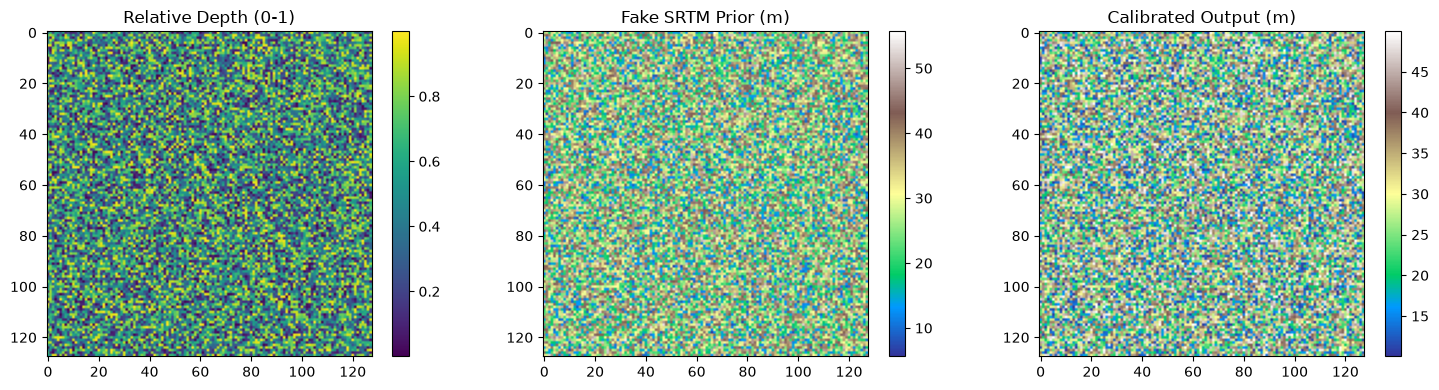

Saved plot -> srtm_calibration_comparison.png


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(fake_relative_depth, cmap='viridis')
axes[0].set_title('Relative Depth (0-1)')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(fake_srtm_prior, cmap='terrain')
axes[1].set_title('Fake SRTM Prior (m)')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(calibrated, cmap='terrain')
axes[2].set_title('Calibrated Output (m)')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.savefig('srtm_calibration_comparison.png', dpi=100)
plt.show()
print("Saved plot -> srtm_calibration_comparison.png")

Using with real data

In [11]:
# target_profile = build_target_profile_from_image('aoi_image.tif')
# srtm_prior = load_srtm_as_prior('srtm_tile.tif', target_profile)
# calibrated = simple_scale_shift_calibration(relative_depth, srtm_prior)
# export_geotiff(calibrated, target_profile, 'srtm_calibrated_output.tif')

print("Uncomment the lines above once you have a real AOI image and SRTM tile.")

Uncomment the lines above once you have a real AOI image and SRTM tile.
